In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [2]:
true_proportions = pd.read_csv("../../../fimm/data/pbmc/true.csv", sep=",", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.082933,0.229503,0.204228,0.012943,0.377872,0.092520
453W_PBMC,0.058854,0.287304,0.320502,0.010775,0.245667,0.076899
4DUY_PBMC,0.105722,0.320983,0.164215,0.009276,0.294850,0.104953
684C_PBMC,0.114487,0.341211,0.177874,0.014584,0.254811,0.097033
925L_PBMC,0.187059,0.231691,0.223318,0.007860,0.234494,0.115577
9JD4_PBMC,0.094967,0.343631,0.269980,0.010984,0.194281,0.086157
CR3L_PBMC,0.137329,0.330611,0.186336,0.016135,0.196571,0.133018
CYFZ_PBMC,0.098471,0.204259,0.327271,0.007765,0.197529,0.164706
CZJE_PBMC,0.148297,0.220536,0.169017,0.018178,0.262195,0.181776
FLWA_PBMC,0.102362,0.289034,0.102056,0.012963,0.255109,0.238477


In [3]:
cs_proportions = pd.read_table("3rd-party/cibersort/pbmc/cibersort_proportions_s.txt", index_col=0)
cs_proportions = cs_proportions.iloc[:, :-3]
cs_proportions = cs_proportions.sort_index(axis="columns").sort_index(axis="rows")
cs_proportions.index.name = None
cs_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.068939,0.303907,0.042039,0.119419,0.437543,0.028153
453W_PBMC,0.039404,0.398498,0.060424,0.075033,0.322808,0.103833
4DUY_PBMC,0.090319,0.492834,0.032243,0.062415,0.303821,0.018368
684C_PBMC,0.135320,0.469621,0.031647,0.108242,0.239560,0.015609
925L_PBMC,0.144502,0.342324,0.101418,0.094925,0.271473,0.045358
9JD4_PBMC,0.091684,0.465329,0.071336,0.082167,0.202487,0.086997
CR3L_PBMC,0.167081,0.469975,0.004817,0.103311,0.234130,0.020686
CYFZ_PBMC,0.106801,0.269063,0.191714,0.072006,0.288245,0.072171
CZJE_PBMC,0.148241,0.368968,0.029069,0.106489,0.312724,0.034509
FLWA_PBMC,0.115911,0.412368,0.025987,0.113707,0.265131,0.066895


In [4]:
deconv_proportions = pd.read_csv("out/pbmc/nb/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.015244,0.063618,0.130250,0.119905,0.557835,0.113147
453W_PBMC,0.018980,0.103670,0.175428,0.103920,0.421903,0.176100
4DUY_PBMC,0.024412,0.116709,0.178306,0.105339,0.420851,0.154383
684C_PBMC,0.023742,0.131454,0.146798,0.116288,0.441000,0.140718
925L_PBMC,0.030519,0.141833,0.155001,0.106119,0.428596,0.137932
9JD4_PBMC,0.025720,0.161097,0.174020,0.107744,0.367966,0.163452
CR3L_PBMC,0.030734,0.113267,0.118915,0.118271,0.473771,0.145042
CYFZ_PBMC,0.015193,0.127156,0.181907,0.121251,0.411733,0.142760
CZJE_PBMC,0.025818,0.111596,0.128914,0.142424,0.441329,0.149918
FLWA_PBMC,0.024182,0.116261,0.150437,0.138409,0.402210,0.168500


In [5]:
music_proportions = pd.read_csv("3rd-party/music/pbmc/music_proportions.csv", index_col=0)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,B.cells,CD4.T,CD8.T,DCs,Monocytes,NK
CR3L_PBMC,0,0,0,0.006391,0.185958,0.807651
CYFZ_PBMC,0,0,0,0.000000,0.133587,0.866413
CZJE_PBMC,0,0,0,0.035314,0.140975,0.823711
FLWA_PBMC,0,0,0,0.042031,0.144699,0.813269
FY2H_PBMC,0,0,0,0.018007,0.197996,0.783997
G4YW_PBMC,0,0,0,0.020229,0.165344,0.814427
X36TS_PBMC,0,0,0,0.063756,0.220126,0.716118
X453W_PBMC,0,0,0,0.011702,0.126811,0.861488
X4DUY_PBMC,0,0,0,0.070702,0.104834,0.824464
X684C_PBMC,0,0,0,0.037561,0.105407,0.857032


In [6]:
scaden_proportions = pd.read_csv("3rd-party/scaden/pbmc/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions.index = pd.read_csv("3rd-party/scaden/pbmc/data/pbmc_bulk_data.txt", sep="\t", index_col=0).columns
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.003563,0.584270,0.000043,0.001859,0.404459,0.005806
453W_PBMC,0.002674,0.716508,0.000047,0.001362,0.272155,0.007254
4DUY_PBMC,0.003598,0.754414,0.000022,0.000762,0.236190,0.005014
684C_PBMC,0.004595,0.755102,0.000038,0.001187,0.234067,0.005011
925L_PBMC,0.010845,0.737469,0.000055,0.001143,0.244674,0.005813
9JD4_PBMC,0.003480,0.779994,0.000026,0.000683,0.210993,0.004825
CR3L_PBMC,0.006806,0.753481,0.000022,0.001138,0.234121,0.004433
CYFZ_PBMC,0.005520,0.720417,0.000063,0.001399,0.264148,0.008453
CZJE_PBMC,0.009826,0.709413,0.000052,0.002275,0.268739,0.009695
FLWA_PBMC,0.003925,0.701876,0.000045,0.001229,0.285183,0.007741


In [7]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt["cs"] = cs_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,deconv,scaden,music,cs
0,36TS_PBMC,B cells,0.082933,0.015244,0.003563,0.000000,0.068939
1,453W_PBMC,B cells,0.058854,0.018980,0.002674,0.000000,0.039404
2,4DUY_PBMC,B cells,0.105722,0.024412,0.003598,0.000000,0.090319
3,684C_PBMC,B cells,0.114487,0.023742,0.004595,0.000000,0.135320
4,925L_PBMC,B cells,0.187059,0.030519,0.010845,0.000000,0.144502
...,...,...,...,...,...,...,...
67,CYFZ_PBMC,NK,0.164706,0.142760,0.008453,0.861488,0.072171
68,CZJE_PBMC,NK,0.181776,0.149918,0.009695,0.824464,0.034509
69,FLWA_PBMC,NK,0.238477,0.168500,0.007741,0.857032,0.066895
70,FY2H_PBMC,NK,0.032445,0.092546,0.007180,0.794733,0.021198


In [8]:
def ccc(est, true):
    p = np.corrcoef(est, true)[0,1]
    mu_est = np.mean(est)
    mu_true = np.mean(true)
    s_est = np.std(est)
    s_true = np.std(true)

    return (2.0 * p * s_est * s_true) / (s_est**2 + s_true**2 + (mu_est - mu_true)**2)

p_deconv = np.corrcoef(melt["true"], melt["deconv"])[0,1]
p_scaden = np.corrcoef(melt["true"], melt["scaden"])[0,1]
p_music = np.corrcoef(melt["true"], melt["music"])[0,1]
p_cs = np.corrcoef(melt["true"], melt["cs"])[0,1]

ccc_deconv = ccc(melt["true"], melt["deconv"])
ccc_scaden = ccc(melt["true"], melt["scaden"])
ccc_music = ccc(melt["true"], melt["music"])
ccc_cs = ccc(melt["true"], melt["cs"])

print("DeconV: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_deconv, ccc_deconv))
print("SCADEN: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_scaden, ccc_scaden))
print("MuSiC: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_music, ccc_music))
print("CIBERSORT: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_cs, ccc_cs))

DeconV: Pearson correlation coefficient: 0.500, CCC: 0.485
SCADEN: Pearson correlation coefficient: 0.656, CCC: 0.453
MuSiC: Pearson correlation coefficient: -0.119, CCC: -0.076
CIBERSORT: Pearson correlation coefficient: 0.688, CCC: 0.666


In [9]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None

melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["music_error"] = abs(melt["music"] - melt["true"])
melt["cs_error"] = abs(melt["cs"] - melt["true"])

temp = melt[["sample", "cell_type", "deconv", "deconv_error"]].rename(columns={"deconv": "proportion", "deconv_error": "error"})
temp["type"] = "deconv"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error"]].rename(columns={"scaden": "proportion", "scaden_error": "error"})
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error"]].rename(columns={"music": "proportion", "music_error": "error"})
temp["type"] = "music"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "cs", "cs_error"]].rename(columns={"cs": "proportion", "cs_error": "error"})
temp["type"] = "cs"
df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error
0,36TS_PBMC,B cells,0.082933,true,NaN
1,453W_PBMC,B cells,0.058854,true,NaN
2,4DUY_PBMC,B cells,0.105722,true,NaN
3,684C_PBMC,B cells,0.114487,true,NaN
4,925L_PBMC,B cells,0.187059,true,NaN
...,...,...,...,...,...
67,CYFZ_PBMC,NK,0.072171,cs,0.092534
68,CZJE_PBMC,NK,0.034509,cs,0.147267
69,FLWA_PBMC,NK,0.066895,cs,0.171582
70,FY2H_PBMC,NK,0.021198,cs,0.011247


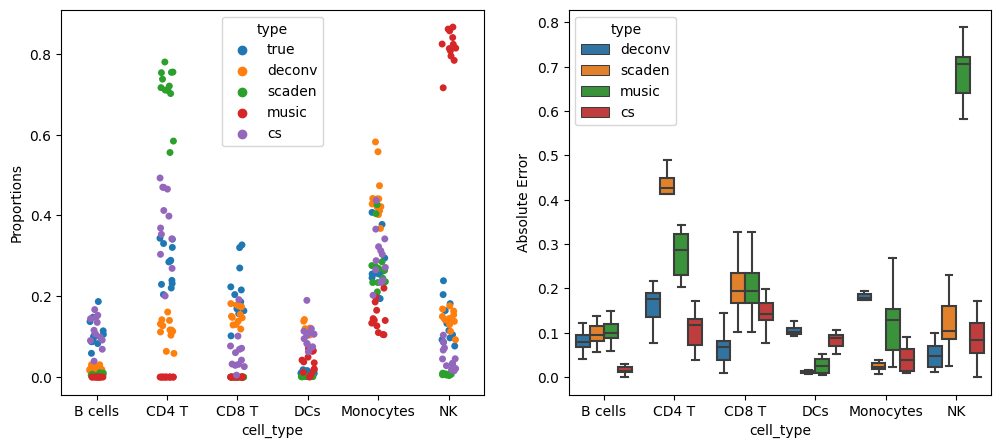

In [10]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0])
# sns.violinplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0], showfliers=False, split=True)
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)
# sns.swarmplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1])
# sns.violinplot(data=melt, x="cell_type", y="dist", ax=ax[1], showfliers=True)
ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
# l = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

<AxesSubplot: xlabel='type', ylabel='error'>

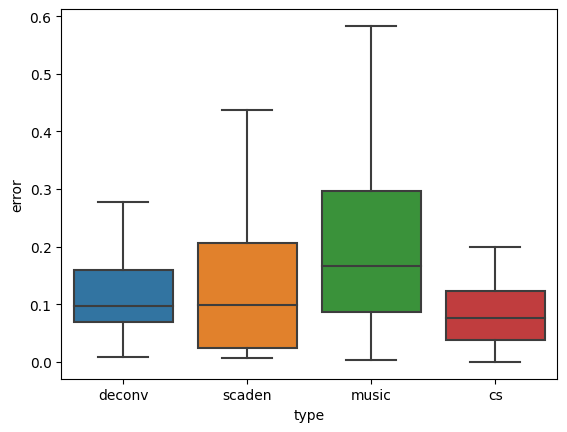

In [11]:
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False)

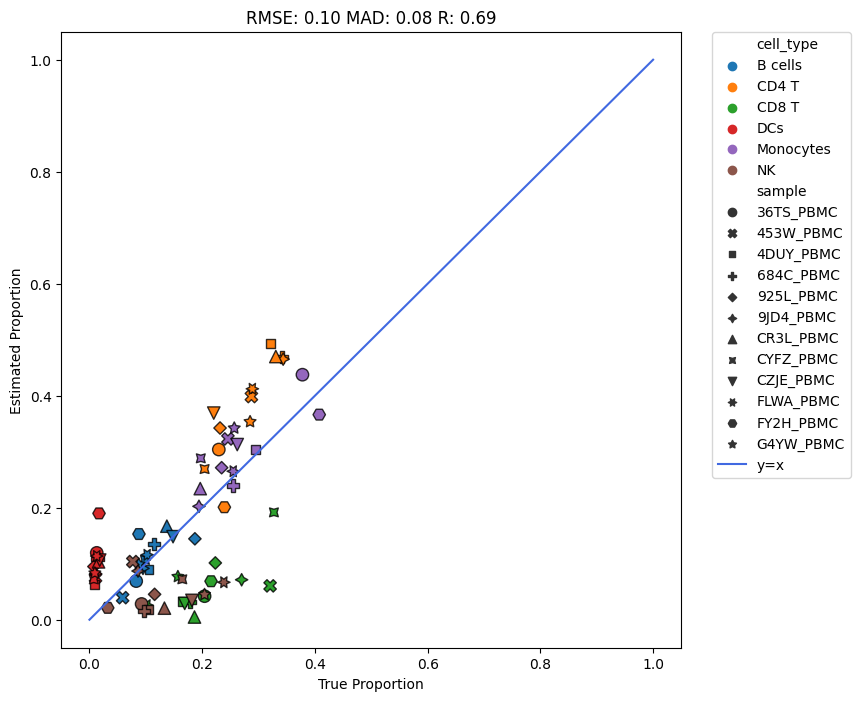

(0.09981549558567647, 0.08243686966989341, 0.6878982192208982)

In [13]:
dv.pl.xypredictions(melt, x="true", y="cs")